<a href="https://colab.research.google.com/github/ruhaan-reza/Maincraft-Internship/blob/main/TitanicAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [17]:
url = "https://raw.githubusercontent.com/ruhaan-reza/Maincraft-Internship/main/titanic%20(1).csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Data Cleaning**

In [19]:
df['Age'].fillna(df['Age'].median(),inplace=True)

In [20]:
df['Fare'].fillna(df['Fare'].median(),inplace=True)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Who survived more: males or females?**

In [22]:
df.groupby("Sex")["Survived"].sum()

,Survived
Sex,
female,233
male,109


In [23]:
df.groupby("Sex")["Survived"].mean()*100

,Survived
Sex,
female,74.203822
male,18.890815


**Did Passenger class effect survival chances?**

In [24]:
result = df.groupby("Pclass")["Survived"].agg(
    Total_Passengers="count",
    Survivors="sum"
)

result.index = ["1st Class", "2nd Class", "3rd Class"]
result.index.name = "Passenger Class"

result

,Total_Passengers,Survivors
Passenger Class,,
1st Class,216,136
2nd Class,184,87
3rd Class,491,119


In [25]:
df.groupby("Pclass")["Survived"].mean() * 100

,Survived
Pclass,
1,62.962963
2,47.282609
3,24.236253


**What was the survival rate by age group?**

In [26]:
bins = [0, 12, 18, 35, 60, 100]
labels = ["Child", "Teen", "Young Adult", "Adult", "Senior"]

df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [27]:
total_passengers = df.groupby("AgeGroup")["Survived"].count()
survivors = df.groupby("AgeGroup")["Survived"].sum()

result = pd.DataFrame({
    "Total Passengers": total_passengers,
    "Survivors": survivors
})

result["Survival Rate (%)"] = (
    result["Survivors"] / result["Total Passengers"] * 100
).round(2)

result

,Total Passengers,Survivors,Survival Rate (%)
AgeGroup,,,
Child,69,40,57.97
Teen,70,30,42.86
Young Adult,535,189,35.33
Adult,195,78,40.00
Senior,22,5,22.73


**Bar chart of survival by gender**

<Axes: title={'center': 'Survivors by Gender'}, xlabel='Gender', ylabel='Number of Survivors'>

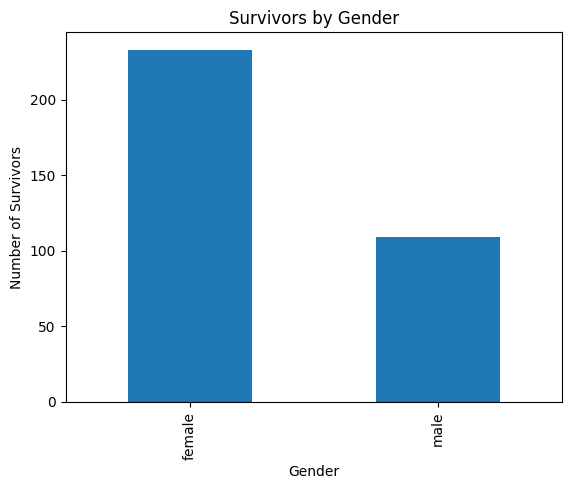

In [28]:
gender_survival = df.groupby("Sex")["Survived"].sum()

gender_survival.plot(
    kind="bar",
    title="Survivors by Gender",
    ylabel="Number of Survivors",
    xlabel="Gender"
)

**Bar chart of survival by class**

<Axes: title={'center': 'Survivors by Passenger Class'}, xlabel='Passenger Class', ylabel='Number of Survivors'>

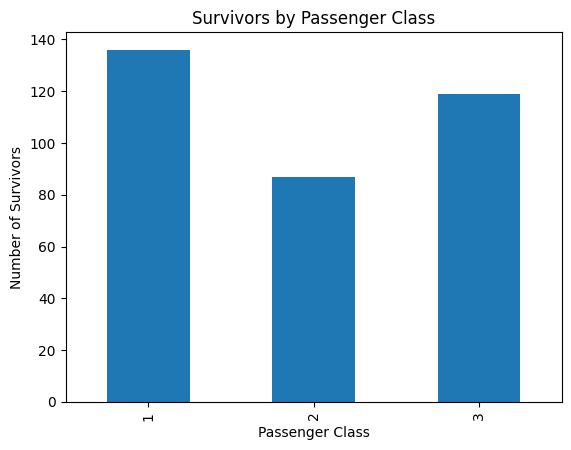

In [29]:
class_survival = df.groupby("Pclass")["Survived"].sum()

class_survival.plot(
    kind="bar",
    title="Survivors by Passenger Class",
    xlabel="Passenger Class",
    ylabel="Number of Survivors"
)

**Histogram of passenger ages**

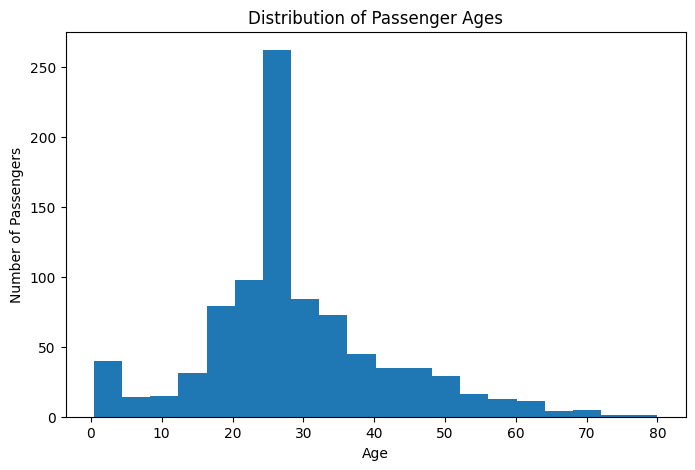

In [30]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"].dropna(), bins=20)

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()